## Read in Params to get to the folder

In [1]:
import sys
pubPath = r'C:\Users\Public\Documents'

if pubPath not in sys.path:
    # append to the path names
    sys.path.append(pubPath)

# imports generic function to obtain path to Project
from generic import getPath

# get path to Project
pth = getPath('trading')
if pth not in sys.path:
    sys.path.append(pth)

# get .py file with functions
from tradfunc import getYFinData, get_ema

## Read in python modules

In [2]:
#from __future__ import (absolute_import, division, print_function, unicode_literals)
# https://www.backtrader.com/docu/quickstart/quickstart/

import datetime  # For datetime objects
import pandas as pd
import ta  # technical analysis
import seaborn as sns
import matplotlib.pyplot as plt

print('Modules imported.')

Modules imported.


## Set TQQQ params to get data

In [3]:
# Parameters
symbol = "TQQQ"
ema_period = 13
start = "2001-01-01"   # adjust start/end as desired
end = None           # None -> up to today

## Get data from Yahoo Finance
#### getYFinData function not shown

In [4]:
df = getYFinData(symbol, start, end)
df =  df.reset_index().rename(columns={'index': 'date'}) # resets index, put date in its own column

df.columns = df.columns.str.lower()  # makes the names of the columns all lower case

print('Shape of DataFrame (rows x columns):',df.shape)
print('\nFirst 2 observations:')
print(df.head(2))

Yahoo Finance data read in
  symbol: TQQQ
  start : 2001-01-01
  end   : None

Shape of DataFrame: (4105, 5)

Summary of DataFrame:
              Close         High          Low         Open        Volume
count  4105.000000  4105.000000  4105.000000  4105.000000  4.105000e+03
mean     12.336313    12.585698    12.049329    12.333788  1.665507e+08
std      15.303034    15.581356    14.966860    15.297602  1.071472e+08
min       0.180475     0.184048     0.168714     0.181939  6.912000e+06
25%       1.215144     1.231717     1.198371     1.218121  9.404160e+07
50%       5.634805     5.803935     5.498527     5.626012  1.375150e+08
75%      19.636307    20.096460    19.074442    19.524904  2.036562e+08
max      87.220001    88.089996    85.410004    87.680000  1.094342e+09
Shape of DataFrame (rows x columns): (4105, 6)

First 2 observations:
        date     close      high       low      open    volume
0 2010-02-11  0.206055  0.207172  0.193203  0.193824   6912000
1 2010-02-12  0.206898 

## Outline

In [ ]:
'''
1 create 3 scenarios
2 subset to just these cases
  -> how often are they by year?
3 calc hi/low/close compared to open
  -> profit using open/close?
4 calculate stop-loss & profit-target
  -> are then contained within hi/low?
  -> how often
'''

## SCENARIO 1: TREND

### Get Exponential Moving Average (EMA)

In [5]:
df = get_ema(df, 13)
varlist = ['date','open','close','ema13']
df[varlist].head()

,date,open,close,ema13
0,2010-02-11,0.193824,0.206055,0.206055
1,2010-02-12,0.200448,0.206898,0.206176
2,2010-02-16,0.211762,0.214913,0.207424
3,2010-02-17,0.217791,0.218560,0.209015
4,2010-02-18,0.218337,0.222704,0.210970


### Create flag for Scenario 1

In [6]:
def scenario_one(row):
    """
    Checks for Scenario 1: Trend
    Trend: prev day's close > 13 EMA (13 day moving average)
        NOTE:  Uses close and EMA from same day -> will shift forward outside of this function
    """
    import numpy as np

    flag = 'x' # default starting value
    if np.isnan(row.close) == True:
        flag = 'na'
    elif row.close > row.ema13:
        flag = 'GO'
    else:
        flag = 'no'  # indicates and issue

    return flag

In [7]:
print('CHECK: curr_days_sc1_flag compares close to EMA13')
print('CHECK: scenario_1 uses previous day\'s curr_days_sc1_flag')

df['curr_days_sc1_flag'] = df.apply(scenario_one, axis=1)
df['scenario_1'] = df['curr_days_sc1_flag'].shift(1)

varlist = ['date','ema13','close','curr_days_sc1_flag','scenario_1']
df[varlist].head()

CHECK: curr_days_sc1_flag compares close to EMA13
CHECK: scenario_1 uses previous day's curr_days_sc1_flag


,date,ema13,close,curr_days_sc1_flag,scenario_1
0,2010-02-11,0.206055,0.206055,no,None
1,2010-02-12,0.206176,0.206898,GO,no
2,2010-02-16,0.207424,0.214913,GO,GO
3,2010-02-17,0.209015,0.218560,GO,GO
4,2010-02-18,0.210970,0.222704,GO,GO


In [8]:
df['scenario_1'].value_counts(dropna=False).sort_index()

scenario_1
GO      2640
no      1464
None       1
Name: count, dtype: int64

## Scenario 2: Momentum

In [9]:
'''
Originally: Momentum: premarket gap > 1.05 * yesterday's close
    (open > (1 + p/100) * prev_close
'''

df['prev_close'] = df['close'].shift(1)
df['momentum'] = df['open'] - df['prev_close']

varlist = ['date','open','prev_close','momentum']
print(df[varlist].head(3))
print('---x---')

def scenario_two(row):
    """  
    Creates a flag for if the momentum is positive, negative or zero.
    Go sign: premarket gap (open) > * yesterday's close
    """
    import numpy as np

    flag = 'x' # default starting value
    if np.isnan(row.momentum) == True:
        flag = 'na'
    elif row.momentum > 0:
        flag = 'GO'
    else:
        flag = 'no'  # indicates and issue

    return flag

df['scenario_2'] = df.apply(scenario_two,axis=1)

varlist = ['open','prev_close','momentum','scenario_2']
print(df[varlist].head())
print('---x---')
print(df['scenario_2'].value_counts(dropna=False).sort_index())

        date      open  prev_close  momentum
0 2010-02-11  0.193824         NaN       NaN
1 2010-02-12  0.200448    0.206055 -0.005607
2 2010-02-16  0.211762    0.206898  0.004864
---x---
       open  prev_close  momentum scenario_2
0  0.193824         NaN       NaN         na
1  0.200448    0.206055 -0.005607         no
2  0.211762    0.206898  0.004864         GO
3  0.217791    0.214913  0.002878         GO
4  0.218337    0.218560 -0.000223         no
---x---
scenario_2
GO    2327
na       1
no    1777
Name: count, dtype: int64


## Scenario 3: Volatility

In [10]:
'''
Volatility: ATR(20) / Close < 0.07 (gen'l met)
ATR(20) = 20-day average true range
'''

from ta.volatility import AverageTrueRange
# compute ATR for period = 20 (example); use fillna=True to avoid initial NaNs
atr = AverageTrueRange(high=df["high"], low=df["low"], close=df["close"], window=20, fillna=True)
df["atr_20"] = atr.average_true_range()
df['atr_div_close'] = df['atr_20'] / df['close']

varlist = ['date','atr_20','close','atr_div_close']
print(df[varlist].head(30))

def scenario_three(row):
    """  
    Creates a flag for Volatility: ATR(20) / Close.
    Note: ATR(20) = 20-day average true range.
    If ATR(20) >, < or = to a 0.07.
    """
    import numpy as np

    flag = 'x' # default starting value
    threshold = 0.07
    
    if np.isnan(row.atr_div_close) == True:
        flag = 'na'
    elif ((row.atr_div_close > 0) and (row.atr_div_close < threshold)):
        flag = 'GO'
    else:
        flag = 'no'  # indicates and issue

    return flag


df['scenario_3'] = df.apply(scenario_three, axis = 1)
print('---x---')
varlist = ['date','atr_20','close','atr_div_close','scenario_3']
print(df[varlist][29:35])
print('---x---')
print(df['scenario_3'].value_counts(dropna=False).sort_index())

         date    atr_20     close  atr_div_close
0  2010-02-11  0.000000  0.206055       0.000000
1  2010-02-12  0.000000  0.206898       0.000000
2  2010-02-16  0.000000  0.214913       0.000000
3  2010-02-17  0.000000  0.218560       0.000000
4  2010-02-18  0.000000  0.222704       0.000000
5  2010-02-19  0.000000  0.222704       0.000000
6  2010-02-22  0.000000  0.221140       0.000000
7  2010-02-23  0.000000  0.212506       0.000000
8  2010-02-24  0.000000  0.218933       0.000000
9  2010-02-25  0.000000  0.218808       0.000000
10 2010-02-26  0.000000  0.221537       0.000000
11 2010-03-01  0.000000  0.231040       0.000000
12 2010-03-02  0.000000  0.232429       0.000000
13 2010-03-03  0.000000  0.233720       0.000000
14 2010-03-04  0.000000  0.236300       0.000000
15 2010-03-05  0.000000  0.246745       0.000000
16 2010-03-08  0.000000  0.248061       0.000000
17 2010-03-09  0.000000  0.252452       0.000000
18 2010-03-10  0.000000  0.258630       0.000000
19 2010-03-11  0.008

In [11]:
varlist = ['scenario_1','scenario_2','scenario_3']
df[varlist].value_counts(dropna=False).sort_index()

scenario_1  scenario_2  scenario_3
GO          GO          GO            1408
                        no              88
            no          GO            1053
                        no              91
no          GO          GO             647
                        no             184
            no          GO             429
                        no             204
NaN         na          no               1
Name: count, dtype: int64

In [ ]:
df.shape

In [12]:
s1 = df.scenario_1 =='GO'
s2 = df.scenario_2 == 'GO' 
s3 = df.scenario_3 == 'GO'

trades = df[((s1==True) & (s2==True) & (s3==True))]
print(trades.shape)

(1408, 15)


In [13]:
trades = trades.astype({'date': 'datetime64[ns]'}) 
trades.dtypes

date                  datetime64[ns]
close                        float64
high                         float64
low                          float64
open                         float64
volume                         int64
ema13                        float64
curr_days_sc1_flag            object
scenario_1                    object
prev_close                   float64
momentum                     float64
scenario_2                    object
atr_20                       float64
atr_div_close                float64
scenario_3                    object
dtype: object

In [14]:
trades['year'] = trades['date'].dt.year
trades.head(3)

,date,close,high,low,open,volume,ema13,curr_days_sc1_flag,scenario_1,prev_close,momentum,scenario_2,atr_20,atr_div_close,scenario_3,year
20,2010-03-12,0.261607,0.263890,0.258605,0.263890,36134400,0.243510,GO,GO,0.261011,0.002878,GO,0.007946,0.030373,GO,2010
22,2010-03-16,0.264759,0.265503,0.259672,0.262401,46579200,0.248546,GO,GO,0.259845,0.002556,GO,0.007810,0.029500,GO,2010
23,2010-03-17,0.266594,0.270365,0.264386,0.265503,39820800,0.251124,GO,GO,0.264759,0.000744,GO,0.007719,0.028953,GO,2010


In [15]:
trades['year'].value_counts(dropna=False).sort_index()

year
2010     79
2011     58
2012     86
2013    110
2014    107
2015     75
2016     82
2017    114
2018     80
2019    108
2020     89
2021    100
2022     14
2023     80
2024     94
2025     97
2026     35
Name: count, dtype: int64

In [ ]:
trades.head()

## Calculate Stop-loss and Profit-Target

In [ ]:
'''
X create 3 scenarios
X subset to just these cases
  -> how often are they by year?

4 calculate stop-loss & profit-target
  -> are then contained within hi/low?
  -> how often

3 calc hi/low/close compared to open
  -> profit using open/close?
'''

In [16]:
'''
Stop Loss: Exit when loss:  Price = Entry - ATR(20)
Profit Target: Price = Entry + 2 * ATR(20) 
'''
trades['stop_loss'] = trades['open'] - df['atr_20']
trades['profit_target'] = trades['open'] + 2 * df['atr_20'] 

varlist = ['date','open','atr_20','stop_loss','profit_target']
trades[varlist][18:30]

,date,open,atr_20,stop_loss,profit_target
87,2010-06-17,0.246199,0.016860,0.229340,0.279918
88,2010-06-18,0.246100,0.016386,0.229714,0.278873
89,2010-06-21,0.254461,0.016594,0.237867,0.287649
104,2010-07-13,0.214839,0.014404,0.200435,0.243646
105,2010-07-14,0.218957,0.014091,0.204867,0.247139
110,2010-07-21,0.222803,0.014353,0.208450,0.251508
113,2010-07-26,0.227889,0.014011,0.213879,0.255911
114,2010-07-27,0.235307,0.013681,0.221626,0.262670
116,2010-07-29,0.230246,0.013686,0.216560,0.257619
118,2010-08-02,0.231462,0.013738,0.217724,0.258938


### Make flags to see when stop-loss is triggered and/or profit target is met

In [27]:
def make_lossflag(row):
    """ Checks if low < stop-loss (meaning stopped out)."""
    flag = 'x'
    if row['low'] > row['stop_loss']:
        flag = 'loss'
    else:
        flag = 'no'
    return flag

def make_profitflag(row):
    """ Checks if hi > profit target."""
    flag = 'x'
    if row['profit_target'] < row['high']:
        flag = 'profit'
    else:
        flag = 'no'
    return flag

In [28]:
def make_loss_profit(df):
    """ Creates the stop-loss, profit-target and their flags. """
    df['loss_flag'] = df.apply(make_lossflag,axis = 1)
    print(df['loss_flag'].value_counts(dropna=False).sort_index())
    print('')
    
    # flag for profits
    df['profit_flag'] = df.apply(make_profitflag, axis=1)
    print(df['profit_flag'].value_counts(dropna=False).sort_index())
    print('')
    
    varlist = ['date','low','stop_loss','loss_flag','high','profit_target','profit_flag']
    print(df[varlist].head())

    return df

trades = make_loss_profit(trades)

loss_flag
loss    1261
no       147
Name: count, dtype: int64

profit_flag
no    1408
Name: count, dtype: int64

         date       low  stop_loss loss_flag      high  profit_target  \
20 2010-03-12  0.258605   0.255944      loss  0.263890       0.279781   
22 2010-03-16  0.259672   0.254591      loss  0.265503       0.278022   
23 2010-03-17  0.264386   0.257784      loss  0.270365       0.280940   
24 2010-03-18  0.265750   0.259959      loss  0.270142       0.282617   
27 2010-03-23  0.269298   0.265472      loss  0.277958       0.289678   

   profit_flag  
20          no  
22          no  
23          no  
24          no  
27          no  


## Examine what could be a profit target

In [19]:
varlist = ['date','high','atr_20','profit_target']
trades[varlist].head()

,date,high,atr_20,profit_target
20,2010-03-12,0.263890,0.007946,0.279781
22,2010-03-16,0.265503,0.007810,0.278022
23,2010-03-17,0.270365,0.007719,0.280940
24,2010-03-18,0.270142,0.007552,0.282617
27,2010-03-23,0.277958,0.008069,0.289678


In [20]:
trades['hi_minus_open'] = trades['high'] - trades['open']
trades['hi_open_div_atr20'] = trades['hi_minus_open'] / trades['atr_20']
    
varlist = ['date','high','open','atr_20', 'hi_minus_open','hi_open_div_atr20']
trades[varlist].head()

,date,high,open,atr_20,hi_minus_open,hi_open_div_atr20
20,2010-03-12,0.263890,0.263890,0.007946,0.000000,0.000000
22,2010-03-16,0.265503,0.262401,0.007810,0.003101,0.397064
23,2010-03-17,0.270365,0.265503,0.007719,0.004863,0.629995
24,2010-03-18,0.270142,0.267512,0.007552,0.002631,0.348302
27,2010-03-23,0.277958,0.273541,0.008069,0.004417,0.547410


In [21]:
trades['hi_open_div_atr20'].describe()

count    1408.000000
mean        0.365072
std         0.296276
min         0.000000
25%         0.135138
50%         0.295537
75%         0.529610
max         1.900966
Name: hi_open_div_atr20, dtype: float64

In [22]:
trades['hi_open_div_atr20'].median()

np.float64(0.2955369144842629)

In [23]:
trades['open_minus_lo'] = trades['open'] - trades['low']
trades['open_low_div_atr20'] = trades['open_minus_lo'] / trades['atr_20']
    
varlist = ['date','open','low','atr_20', 'open_minus_lo','open_low_div_atr20']
trades[varlist].head()

,date,open,low,atr_20,open_minus_lo,open_low_div_atr20
20,2010-03-12,0.263890,0.258605,0.007946,0.005285,0.665110
22,2010-03-16,0.262401,0.259672,0.007810,0.002730,0.349487
23,2010-03-17,0.265503,0.264386,0.007719,0.001117,0.144663
24,2010-03-18,0.267512,0.265750,0.007552,0.001762,0.233252
27,2010-03-23,0.273541,0.269298,0.008069,0.004243,0.525796


In [24]:
trades['open_low_div_atr20'].describe()

count    1408.000000
mean        0.473892
std         0.447747
min         0.000000
25%         0.156801
50%         0.350364
75%         0.641686
max         4.820635
Name: open_low_div_atr20, dtype: float64

In [25]:
trades['open_low_div_atr20'].median()

np.float64(0.3503635373671646)

In [ ]:
trades.columns

In [26]:
varlist = ['date','open','low','stop_loss']
trades[varlist].head()

,date,open,low,stop_loss
20,2010-03-12,0.263890,0.258605,0.255944
22,2010-03-16,0.262401,0.259672,0.254591
23,2010-03-17,0.265503,0.264386,0.257784
24,2010-03-18,0.267512,0.265750,0.259959
27,2010-03-23,0.273541,0.269298,0.265472


In [34]:
trades['hi_minus_low'] = trades['high'] - trades['low']

In [35]:
varlist = ['date','high','low','hi_minus_low']
trades[varlist].head()

,date,high,low,hi_minus_low
20,2010-03-12,0.263890,0.258605,0.005285
22,2010-03-16,0.265503,0.259672,0.005831
23,2010-03-17,0.270365,0.264386,0.005979
24,2010-03-18,0.270142,0.265750,0.004392
27,2010-03-23,0.277958,0.269298,0.008659


In [37]:
trades['hi_minus_low'].describe()

count    1408.000000
mean        0.433061
std         0.635865
min         0.003027
25%         0.028735
50%         0.118054
75%         0.664341
max         6.394400
Name: hi_minus_low, dtype: float64

<Axes: xlabel='date', ylabel='hi_minus_low'>

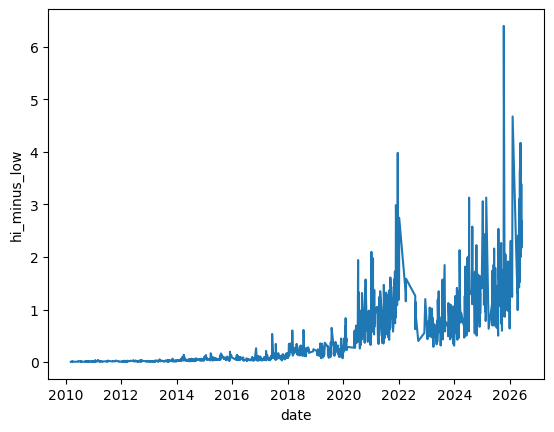

In [36]:
sns.lineplot(data = trades, x=trades['date'], y=trades['hi_minus_low'])

<Axes: xlabel='date', ylabel='hi_minus_open'>

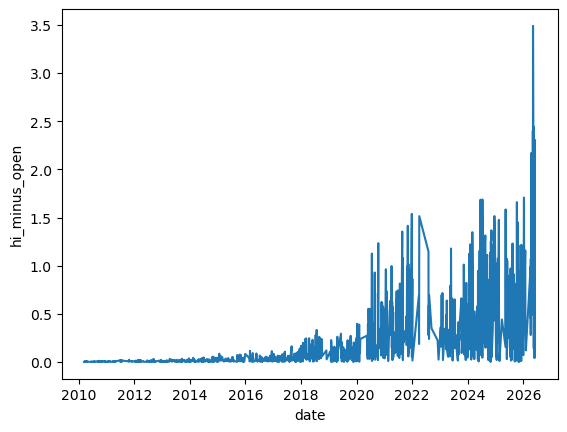

In [39]:
sns.lineplot(data = trades, x=trades['date'], y=trades['hi_minus_open'])

<Axes: xlabel='date', ylabel='volume'>

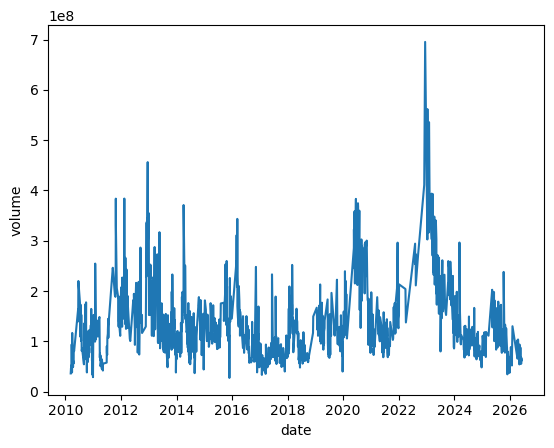

In [40]:
sns.lineplot(data = trades, x=trades['date'], y=trades['volume'])

In [41]:
trades.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'ema13',
       'curr_days_sc1_flag', 'scenario_1', 'prev_close', 'momentum',
       'scenario_2', 'atr_20', 'atr_div_close', 'scenario_3', 'year',
       'stop_loss', 'profit_target', 'loss_flag', 'profit_flag',
       'hi_minus_open', 'hi_open_div_atr20', 'open_minus_lo',
       'open_low_div_atr20', 'hi_minus_low'],
      dtype='object')

<Axes: xlabel='date', ylabel='high'>

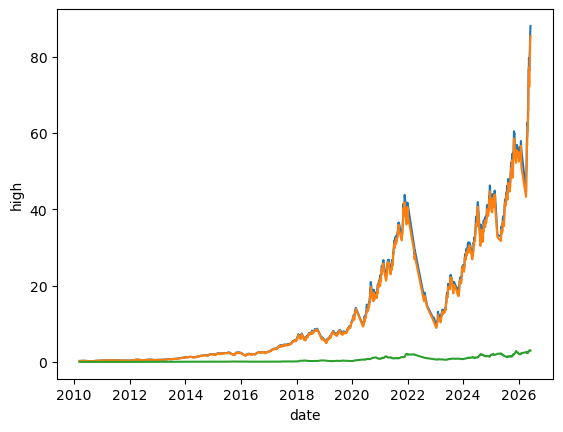

In [42]:
sns.lineplot(data = trades, x=trades['date'], y=trades['high'])
sns.lineplot(data = trades, x=trades['date'], y=trades['low'])
sns.lineplot(data = trades, x=trades['date'], y=trades['atr_20'])

<Axes: xlabel='date', ylabel='atr_20'>

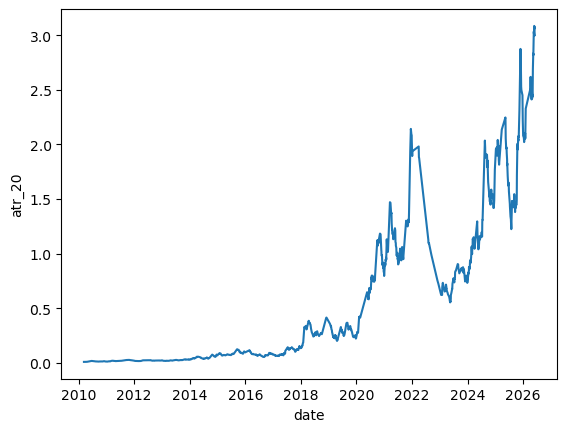

In [43]:
sns.lineplot(data = trades, x=trades['date'], y=trades['atr_20'])

In [53]:
trades.T

,20,22,23,24,27,29,30,31,32,34,...,4087,4088,4090,4092,4094,4095,4096,4097,4098,4101
date,2010-03-12 00:00:00,2010-03-16 00:00:00,2010-03-17 00:00:00,2010-03-18 00:00:00,2010-03-23 00:00:00,2010-03-25 00:00:00,2010-03-26 00:00:00,2010-03-29 00:00:00,2010-03-30 00:00:00,2010-04-01 00:00:00,...,2026-05-13 00:00:00,2026-05-14 00:00:00,2026-05-18 00:00:00,2026-05-20 00:00:00,2026-05-22 00:00:00,2026-05-26 00:00:00,2026-05-27 00:00:00,2026-05-28 00:00:00,2026-05-29 00:00:00,2026-06-03 00:00:00
close,0.261607,0.264759,0.266594,0.269298,0.277362,0.271705,0.27312,0.276866,0.279769,0.275452,...,77.239998,78.949997,74.32,76.510002,77.839996,81.949997,81.669998,83.68,84.559998,86.559998
high,0.26389,0.265503,0.270365,0.270142,0.277958,0.283019,0.278354,0.279695,0.282176,0.284409,...,77.940002,79.68,76.269997,76.529999,79.330002,82.269997,82.910004,84.050003,85.699997,88.089996
low,0.258605,0.259672,0.264386,0.26575,0.269298,0.271482,0.268827,0.274832,0.274087,0.269274,...,74.190002,77.160004,72.099998,73.620003,77.330002,79.980003,80.330002,80.660004,83.529999,85.410004
open,0.26389,0.262401,0.265503,0.267512,0.273541,0.280091,0.275576,0.277239,0.279149,0.279075,...,75.809998,77.290001,76.129997,74.089996,78.040001,80.589996,82.870003,81.739998,84.410004,87.68
volume,36134400,46579200,39820800,52185600,55334400,93926400,84288000,38054400,39897600,116620800,...,64416400,58472800,87710100,70647500,58330500,62579600,66221000,55265900,67644100,62154500
ema13,0.24351,0.248546,0.251124,0.25372,0.260432,0.263632,0.264988,0.266685,0.268554,0.270451,...,69.735006,71.051433,72.043501,72.790124,74.020906,75.153634,76.084543,77.169608,78.225378,81.337614
curr_days_sc1_flag,GO,GO,GO,GO,GO,GO,GO,GO,GO,GO,...,GO,GO,GO,GO,GO,GO,GO,GO,GO,GO
scenario_1,GO,GO,GO,GO,GO,GO,GO,GO,GO,GO,...,GO,GO,GO,GO,GO,GO,GO,GO,GO,GO
prev_close,0.261011,0.259845,0.264759,0.266594,0.27168,0.273417,0.271705,0.27312,0.276866,0.275998,...,74.959999,77.239998,75.339996,72.93,76.949997,77.839996,81.949997,81.669998,83.68,87.220001


In [54]:
varlist = ['close', 'high', 'low', 'open', 'volume', 'ema13',
           'prev_close', 'momentum','atr_20', 'atr_div_close', 'year',
           'stop_loss', 'profit_target', 
           'hi_minus_open', 'hi_open_div_atr20', 'open_minus_lo',
           'open_low_div_atr20', 'hi_minus_low']

x = trades[varlist]
print(trades.shape, x.shape)

(1408, 25) (1408, 18)


In [56]:
x.corr()

,close,high,low,open,volume,ema13,prev_close,momentum,atr_20,atr_div_close,year,stop_loss,profit_target,hi_minus_open,hi_open_div_atr20,open_minus_lo,open_low_div_atr20,hi_minus_low
close,1.000000,0.999796,0.999889,0.999586,-0.092514,0.998975,0.999460,0.628734,0.962373,0.143582,0.847348,0.999499,0.999425,0.718172,0.053669,0.619552,0.000679,0.862652
high,0.999796,1.000000,0.999816,0.999888,-0.087914,0.999272,0.999766,0.628736,0.962921,0.145817,0.847980,0.999790,0.999746,0.713718,0.049789,0.632685,0.010638,0.869939
low,0.999889,0.999816,1.000000,0.999751,-0.094298,0.999203,0.999649,0.627635,0.961566,0.141766,0.847498,0.999704,0.999519,0.711352,0.048172,0.621524,0.002386,0.860308
open,0.999586,0.999888,0.999751,1.000000,-0.088900,0.999409,0.999884,0.628508,0.962200,0.144333,0.847913,0.999936,0.999797,0.703151,0.040706,0.638841,0.015702,0.868614
volume,-0.092514,-0.087914,-0.094298,-0.088900,1.000000,-0.093323,-0.091250,0.064660,-0.012276,0.511057,0.049818,-0.091929,-0.083462,-0.016159,0.037261,0.130182,0.258461,0.087878
ema13,0.998975,0.999272,0.999203,0.999409,-0.093323,1.000000,0.999443,0.620435,0.960361,0.141016,0.848931,0.999398,0.999112,0.701568,0.042102,0.636993,0.014141,0.866354
prev_close,0.999460,0.999766,0.999649,0.999884,-0.091250,0.999443,1.000000,0.616585,0.961179,0.142024,0.847413,0.999858,0.999614,0.702791,0.041010,0.638283,0.015365,0.867998
momentum,0.628734,0.628736,0.627635,0.628508,0.064660,0.620435,0.616585,1.000000,0.651167,0.207733,0.553433,0.626545,0.631814,0.456142,0.009835,0.426207,0.027016,0.572252
atr_20,0.962373,0.962921,0.961566,0.962200,-0.012276,0.960361,0.961179,0.651167,1.000000,0.316034,0.840433,0.959066,0.967492,0.715935,0.031224,0.628287,-0.009994,0.867904
atr_div_close,0.143582,0.145817,0.141766,0.144333,0.511057,0.141016,0.142024,0.207733,0.316034,1.000000,0.185928,0.136985,0.157410,0.172770,-0.074864,0.179494,-0.033517,0.230194


<Axes: >

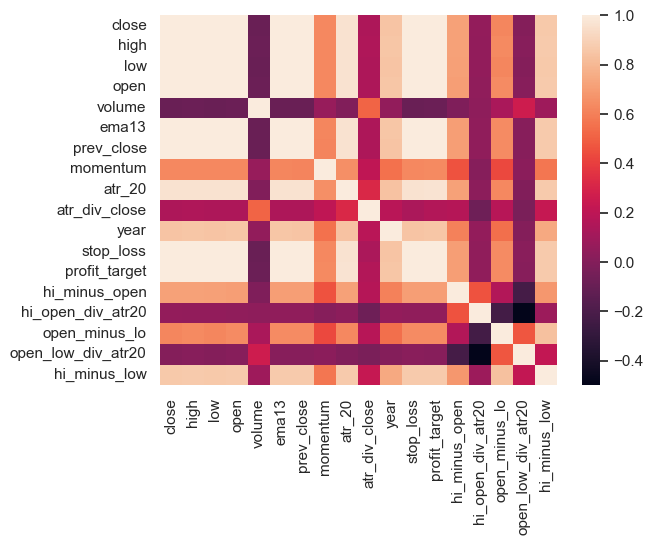

In [60]:
corr = x.corr()
sns.heatmap(corr)